In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
import os
import numpy as np
import librosa
import tensorflow as tf
import pandas as pd

In [ ]:
fake_test_dir = '/content/drive/MyDrive/deepfake_dataset/release_in_the_wild/test/fake'
real_test_dir = '/content/drive/MyDrive/deepfake_dataset/release_in_the_wild/test/real'

In [ ]:
def extract_features(fake_root_dir, real_root_dir, max_length=500):
    features = []
    labels = []

    # FAKE
    for file in os.listdir(fake_root_dir):
        file_path = os.path.join(fake_root_dir, file)
        try:
            audio, _ = librosa.load(file_path, sr=16000)
            mfccs = librosa.feature.mfcc(y=audio, sr=16000, n_mfcc=40)

            if mfccs.shape[1] < max_length:
                mfccs = np.pad(mfccs, ((0, 0), (0, max_length - mfccs.shape[1])), mode='constant')
            else:
                mfccs = mfccs[:, :max_length]

            features.append(mfccs)
            labels.append(1)  # FAKE

        except:
            continue

    # REAL
    for file in os.listdir(real_root_dir):
        file_path = os.path.join(real_root_dir, file)
        try:
            audio, _ = librosa.load(file_path, sr=16000)
            mfccs = librosa.feature.mfcc(y=audio, sr=16000, n_mfcc=40)

            if mfccs.shape[1] < max_length:
                mfccs = np.pad(mfccs, ((0, 0), (0, max_length - mfccs.shape[1])), mode='constant')
            else:
                mfccs = mfccs[:, :max_length]

            features.append(mfccs)
            labels.append(0)  # REAL

        except:
            continue

    return np.array(features), np.array(labels)

In [ ]:
x_test, y_test = extract_features(fake_test_dir, real_test_dir)

print("Test shape:", x_test.shape)

Test shape: (3179, 40, 500)


In [ ]:
model = tf.keras.models.load_model('/content/drive/MyDrive/deepfake_model.h5')

In [ ]:
loss, accuracy = model.evaluate(x_test, y_test)

print("Test Accuracy:", accuracy)
print("Test Loss:", loss)

100/100 ━━━━━━━━━━━━━━━━━━━━ 96s 916ms/step - accuracy: 0.9934 - loss: 0.0278
Test Accuracy: 0.993394136428833
Test Loss: 0.027798643335700035


In [ ]:
pred = model.predict(x_test)

# convert probabilities → 0/1
pred_labels = (pred > 0.5).astype(int)

print("Predictions:", pred_labels[:10])
print("Actual:", y_test[:10])

100/100 ━━━━━━━━━━━━━━━━━━━━ 114s 1s/step
Predictions: [[1]
 [1]
 [1]
 [1]
 [1]
 [1]
 [1]
 [1]
 [1]
 [1]]
Actual: [1 1 1 1 1 1 1 1 1 1]


In [ ]:
from sklearn.metrics import precision_score, recall_score, confusion_matrix, accuracy_score


# Assuming your model is already trained
# X_test, y_test are your test data and true labels
y_pred = model.predict(x_test)
y_pred = (y_pred > 0.5).astype(int)  # Threshold the output to get binary class (0 or 1)

# Calculate precision and recall using sklearn
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
accuracy = accuracy_score(y_test, y_pred)

# Print the precision and recall values
print(f"Accuracy: {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall: {recall:.4f}")

# Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
print("Confusion Matrix:")
print(cm)

100/100 ━━━━━━━━━━━━━━━━━━━━ 92s 917ms/step
Accuracy: 0.9934
Precision: 0.9949
Recall: 0.9873
Confusion Matrix:
[[1991    6]
 [  15 1167]]


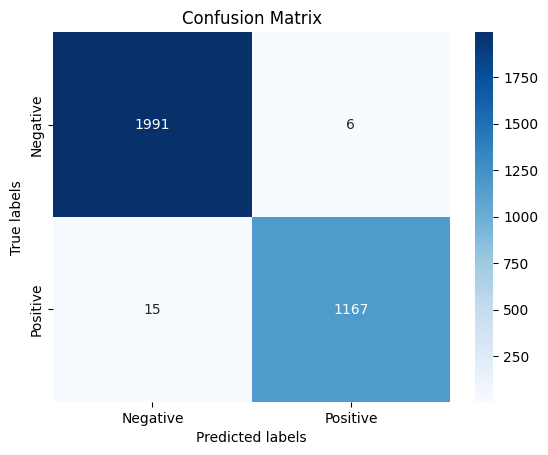

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=['Negative', 'Positive'], yticklabels=['Negative', 'Positive'])
plt.ylabel('True labels')
plt.xlabel('Predicted labels')
plt.title('Confusion Matrix')
plt.show()

In [ ]:
# ek audio file test karo
# Define the audio file path
audio_file_path = '/content/drive/MyDrive/deepfake_dataset/release_in_the_wild/val/real/10031.wav'

# Ensure librosa is imported (it is in an earlier cell, but good practice)
import librosa
import numpy as np
import tensorflow as tf # Added for explicit tf.Tensor conversion

# Extract features for the single audio file
def extract_single_audio_features(file_path, max_length=500):
    audio, sr = librosa.load(file_path, sr=16000)
    mfccs = librosa.feature.mfcc(y=audio, sr=sr, n_mfcc=40)

    if mfccs.shape[1] < max_length:
        # Pad if shorter
        mfccs = np.pad(mfccs, ((0, 0), (0, max_length - mfccs.shape[1])), mode='constant')
    else:
        # Trim if longer
        mfccs = mfccs[:, :max_length]
    return mfccs

# Get features for the specific audio file
single_audio_features = extract_single_audio_features(audio_file_path)

# Reshape for the model: (batch_size, n_mfcc, max_length)
single_audio_features = single_audio_features[np.newaxis, ...]

# Make prediction
# Explicitly convert to TensorFlow Tensor to ensure shape is fully known
single_audio_features_tensor = tf.constant(single_audio_features, dtype=tf.float32)
result = model.predict(single_audio_features_tensor)

# Interpret result
pred = result[0][0]

if pred > 0.5:
    print("Fake Audio")
    confidence = pred * 100
else:
    print("Real Audio")
    confidence = (1 - pred) * 100

print(f"Confidence: {confidence:.2f}%")

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 646ms/step
Real Audio
Confidence: 100.00%


In [ ]:
# ek audio file test karo
# Define the audio file path
audio_file_path = '/content/drive/MyDrive/deepfake_dataset/release_in_the_wild/val/fake/10062.wav'

# Ensure librosa is imported (it is in an earlier cell, but good practice)
import librosa
import numpy as np
import tensorflow as tf # Added for explicit tf.Tensor conversion

# Extract features for the single audio file
def extract_single_audio_features(file_path, max_length=500):
    audio, sr = librosa.load(file_path, sr=16000)
    mfccs = librosa.feature.mfcc(y=audio, sr=sr, n_mfcc=40)

    if mfccs.shape[1] < max_length:
        # Pad if shorter
        mfccs = np.pad(mfccs, ((0, 0), (0, max_length - mfccs.shape[1])), mode='constant')
    else:
        # Trim if longer
        mfccs = mfccs[:, :max_length]
    return mfccs

# Get features for the specific audio file
single_audio_features = extract_single_audio_features(audio_file_path)

# Reshape for the model: (batch_size, n_mfcc, max_length)
single_audio_features = single_audio_features[np.newaxis, ...]

# Make prediction
# Explicitly convert to TensorFlow Tensor to ensure shape is fully known
single_audio_features_tensor = tf.constant(single_audio_features, dtype=tf.float32)
result = model.predict(single_audio_features_tensor)

# Interpret result
pred = result[0][0]

if pred > 0.5:
    print("Fake Audio")
    confidence = pred * 100
else:
    print("Real Audio")
    confidence = (1 - pred) * 100

print(f"Confidence: {confidence:.2f}%")

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 332ms/step
Fake Audio
Confidence: 100.00%
